![head.png](figures/head.jpg)

# Financial Data Analytics in Python

**Prof. Dr. Fabian Woebbeking**</br>
Assistant Professor of Financial Economics

IWH - Leibniz Institute for Economic Research</br>
MLU - Martin Luther University Halle-Wittenberg

fabian.woebbeking@iwh-halle.de

This notebook covers:
- Web scraping
- Natural language processing (NLP)
- Text preprocessing
- Sentiment analysis
- Word embeddings
- Transformer models
- Prompt engineering
- OpenAI API usage
- LLM tools (e.g. RAG)
- Hallucination risks

In [1]:
# Packages used in this notebook
import requests
from bs4 import BeautifulSoup
import collections
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
import nltk
import numpy as np
import pandas as pd
import configparser
import openai

In [2]:
# Update package stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Web scraping

[Web scraping](https://en.wikipedia.org/wiki/Web_scraping) refers to the **extraction of data from websites**. It's a useful technique for building datasets, especially in situations where data isn't easily accessible via APIs or other direct methods. Before we begin, it's important to mention the ethical and legal considerations associated with web scraping. Always respect the rules of the site you're scraping, including the website's robots.txt file and terms of service.

Python provides several libraries to facilitate web scraping, such as [BeautifulSoup](https://beautiful-soup-4.readthedocs.io/en/latest/), [Scrapy](https://scrapy.org/), and [Requests](https://requests.readthedocs.io/en/latest/). In this class, we'll focus on using BeautifulSoup and Requests.

First, we need to send an HTTP request to the URL of the webpage you want to access. The server responds to the request by returning the HTML content of the webpage. For this task, we'll be using the requests library. The `requests.get()` function sends a **GET request** to the specified url. If the request is successful, the **status code** will be 200. You can check the status code by `response.status_code`.

Once we have accessed the HTML content, we are left with the task of parsing the data. Since most of the HTML data is nested, we cannot extract data simply through string processing (we could, but it's quite annoying). One needs a parser which can create a **nested/tree structure of the HTML data**. Let's try this out using news articles from [https://www.uni-halle.de/](https://www.uni-halle.de/newsarchiv.1.en.php):

In [3]:
# URL of the webpage we want to scrape data from
url = "https://www.uni-halle.de/newsarchiv.1.en.php"
# Sends a GET request to the URL to retrieve its content
response = requests.get(url)
assert response.status_code == 200
print(response.text)

<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:lang="en">
<head>
 <title>Newsarchiv: Creating knowledge since 1502</title>
 <meta http-equiv="content-type" content="text/html;charset=ISO-8859-1" />
 <meta http-equiv="content-script-type" content="text/javascript" />
 <meta name="language" content="en" />
 <meta name="keywords" content="Informationen Uni Halle MLU Martin-Luther-Universität Halle-Wittenberg Informationen Kontakt Lehre Studium Verwaltung "/>
 <meta name="description" content="Startseite der Martin-Luther-Universität Halle-Wittenberg." />
 <meta name="robots" content="follow"/>
 <meta name="robots" content="index"/>
 <link href="/im/sod/common/css/styles.css" rel="stylesheet" type="text/css"/>
 <link rel="stylesheet" href="/im/js/highslide/highslide.css" type="text/css"/>
 <!--<link rel="shortcut icon" href="/im/sod/common/img/favicon.ico" type="image/x

Please note that some, more complex and dynamic (e.g. **JavaScript** based), websites might require a more flexible query tools, such as [Selenium](https://selenium-python.readthedocs.io/). Selenium is an open-source framework commonly used for automating web browsers.

Now that we have created the soup, we can **extract information**. If you want to get a specific element of a page you can use the `soup.find_all` method, which returns all the instances of a tag on a page. Finding the right id can be tedious, a web browser that allows you to 'inspect' the page can be very helpful here.

In [4]:
# Parse results
soup = BeautifulSoup(response.text, 'html.parser')

# Extracting all news sections
news_sections = soup.find_all('div', class_='news')

# Loop through each news section and extract the text
raw_text = ''
for news in news_sections:
    raw_text += news.find('p').get_text()
print(raw_text)

Die Zahl der Arten nimmt nicht gleichmäßig zu, wenn man sich von kleinen Ökosystemen zu kontinentalen Maßstäben bewegt – dieses Phänomen ist in der Ökologie seit Jahrzehnten bekannt. Jetzt hat ein internationales Forschungsteam unter Beteiligung des iDiv und der MLU eine neue Theorie entwickelt, welche die drei Phasen erklärt, die typisch sind für die Verteilung der Arten im Raum. Die Veröffentlichung in der Fachzeitschrift "Nature Communications" könnte helfen abzuschätzen, wie viele Arten durch die Zerstörung von Lebensräumen verloren gehen.Ab in den Hörsaal und in das Museum: Die Kinderuni der MLU startet am Montag, 2. Juni 2025. Neugierige Schülerinnen und Schüler der Klassen 1 bis 6 können an diesem Tag zwischen 9 und 12 Uhr experimentieren und Vorlesungen besuchen. Die weiteren Termine finden an den darauffolgenden Montagen, 16. Juni und 23. Juni 2025, statt. Die Anmeldung ist ab sofort möglich.Mit einem besonderen Angebot wartet die Martin-Luther-Universität zur kommenden Museum

## Working with textual data

Textual analysis in financial economics involves using statistical, linguistic, and machine learning techniques to analyze text data such as financial reports, news articles, social media posts, and other written material to extract useful information for economic decision-making.

See, e.g.:
* https://www.nltk.org/index.html
* https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html

Let's have a look at the textual data that we have scraped from MLU's news archive:

In [5]:
# Counts the frequency of each word in 'raw_text' (note the split function to separate words)
raw_word_frequency = collections.Counter(raw_text.split(" "))
display(raw_word_frequency)

Counter({'Die': 11,
         'Zahl': 1,
         'der': 43,
         'Arten': 3,
         'nimmt': 1,
         'nicht': 1,
         'gleichmäßig': 1,
         'zu,': 1,
         'wenn': 1,
         'man': 1,
         'sich': 6,
         'von': 7,
         'kleinen': 1,
         'Ökosystemen': 1,
         'zu': 6,
         'kontinentalen': 1,
         'Maßstäben': 1,
         'bewegt': 1,
         '–': 1,
         'dieses': 1,
         'Phänomen': 1,
         'ist': 5,
         'in': 18,
         'Ökologie': 1,
         'seit': 1,
         'Jahrzehnten': 1,
         'bekannt.': 1,
         'Jetzt': 1,
         'hat': 1,
         'ein': 1,
         'internationales': 1,
         'Forschungsteam': 1,
         'unter': 1,
         'Beteiligung': 1,
         'des': 5,
         'iDiv': 1,
         'und': 20,
         'MLU': 7,
         'eine': 7,
         'neue': 4,
         'Theorie': 1,
         'entwickelt,': 1,
         'welche': 1,
         'die': 18,
         'drei': 1,
         'Phase

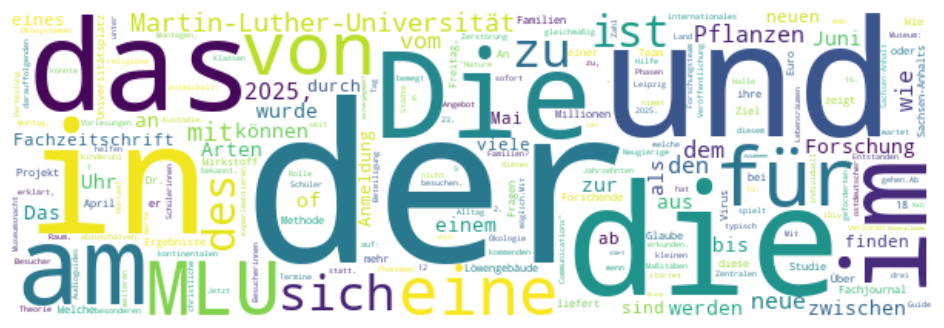

In [6]:
# Generates a Word Cloud image from the word frequencies
wc = WordCloud(width=600, height=200, max_words=200, background_color='white').generate_from_frequencies(raw_word_frequency)
plt.figure(figsize=(12,4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

### Pre-processing

Pre-processing in NLP refers to the preliminary steps involved in transforming raw data (text) into an understandable format. Effective machine learning models are built specifically on well-structured data. In other words, whenever we receive any form of raw data, it's not always in the state we need it to be in. In fact, raw data often has a lot of noise such as punctuation, special characters, numbers, etc., which can often be irrelevant when processing text data.

These are common steps in pre-processing:

* **Tokenization**: It is the process of splitting the text into individual words or tokens.
* **Lowercasing**: All the text is converted into lowercase to ensure the algorithm does not treat the same words in different cases as different.
* **Stop words removal**: This process involves **removing common language** articles like 'a', 'an', 'in', 'the' etc. as they do not contain useful information for NLP tasks.
* **Punctuation removal**: Punctuation can provide grammatical context to a sentence which supports our understanding. But for our vectorizer which counts the number of words and not the context, it does not add value, so we remove all special characters.
* **Stemming**: Stemming is the process of reducing inflected (or sometimes derived) words to their **word stem, base or root form**. For example, the stem of the words 'jumping', 'jumps', 'jumped' is 'jump'.
* **Lemmatization**: Similar to stemming, but lemmatization provides the **base forms of words** known as lemma. Unlike stemming, it converts words to their actual root. For example, 'better' would be converted to 'good'.

### Regular expression (**regex**)

Part of (almost) every textual analysis: [regular expressions (regex)](https://en.wikipedia.org/wiki/Regular_expression) are a powerful tool that is used for **pattern matching** and **manipulation of text strings**. They provide a flexible and concise means to match, locate, and manage text.

A regular expression is a sequence of characters that forms a **search pattern**. This pattern can be used in a search operation to **find a match or to replace** text. The pattern can be a simple string, or it can be a more complex pattern that uses special characters to find a broader range of matches.



Here are some of the common special characters and sequences used in regular expressions:

* '.': Matches any single character except newline
* '*': Matches zero or more occurrences of the preceding character or group
* '+': Matches one or more occurrences of the preceding character or group
* '?': Matches zero or one occurrence of the preceding character or group
* '^': Matches the start of a line
* '$': Matches the end of a line
* '[abc]': Matches any character a, b, or c
* '(abc)': Matches the group of characters 'abc'
* '\d': Matches any digit, equivalent to [0-9]
* '\D': Matches any non-digit character
* '\w': Matches any alphanumeric character or underscore, equivalent to [A-Za-z0-9_]
* '\W': Matches any non-alphanumeric character
* '\s': Matches any whitespace character
* '\S': Matches any non-whitespace character

These are just a few examples, and different languages and tools can have additional features or syntax in their regular expression engines.

A very helpful tool for designing regular expressions is [https://regex101.com/](https://regex101.com/)

In [7]:
# Regex to remove all non-alphabetical characters except German special chars and "-"
processed_text = re.sub('[^a-zA-ZäöüÄÖÜß-]', ' ', raw_text)
# Convert all characters to lowercase 
processed_text = processed_text.lower()
# Split the text into individual words (you could also use 'nltk.tokenize.word_tokenize' or lemming/stemming)
processed_text = processed_text.split()

# Please note that news articles here are in English and German, so we combine both stop words lists
stop_words = set(nltk.corpus.stopwords.words('german') + nltk.corpus.stopwords.words('english'))
# Remove stop words from the processed text
processed_text = [word for word in processed_text if word not in stop_words]

print(processed_text)

['zahl', 'arten', 'nimmt', 'gleichmäßig', 'kleinen', 'ökosystemen', 'kontinentalen', 'maßstäben', 'bewegt', 'phänomen', 'ökologie', 'seit', 'jahrzehnten', 'bekannt', 'internationales', 'forschungsteam', 'beteiligung', 'idiv', 'mlu', 'neue', 'theorie', 'entwickelt', 'drei', 'phasen', 'erklärt', 'typisch', 'verteilung', 'arten', 'raum', 'veröffentlichung', 'fachzeitschrift', 'nature', 'communications', 'helfen', 'abzuschätzen', 'viele', 'arten', 'zerstörung', 'lebensräumen', 'verloren', 'gehen', 'ab', 'hörsaal', 'museum', 'kinderuni', 'mlu', 'startet', 'montag', 'juni', 'neugierige', 'schülerinnen', 'schüler', 'klassen', 'tag', 'uhr', 'experimentieren', 'vorlesungen', 'besuchen', 'weiteren', 'termine', 'finden', 'darauffolgenden', 'montagen', 'juni', 'juni', 'statt', 'anmeldung', 'ab', 'sofort', 'möglich', 'besonderen', 'angebot', 'wartet', 'martin-luther-universität', 'kommenden', 'museumsnacht', 'städte', 'halle', 'leipzig', 'mai', 'hilfe', 'neuen', 'audioguides', 'besucherinnen', 'bes

In [8]:
# Counts the frequency of each word in 'processed_text'
word_frequency = collections.Counter(processed_text)
display(word_frequency)

Counter({'zahl': 1,
         'arten': 3,
         'nimmt': 1,
         'gleichmäßig': 1,
         'kleinen': 1,
         'ökosystemen': 1,
         'kontinentalen': 1,
         'maßstäben': 1,
         'bewegt': 1,
         'phänomen': 1,
         'ökologie': 1,
         'seit': 1,
         'jahrzehnten': 1,
         'bekannt': 1,
         'internationales': 1,
         'forschungsteam': 1,
         'beteiligung': 1,
         'idiv': 1,
         'mlu': 8,
         'neue': 4,
         'theorie': 1,
         'entwickelt': 2,
         'drei': 1,
         'phasen': 1,
         'erklärt': 1,
         'typisch': 1,
         'verteilung': 1,
         'raum': 1,
         'veröffentlichung': 1,
         'fachzeitschrift': 2,
         'nature': 1,
         'communications': 1,
         'helfen': 1,
         'abzuschätzen': 1,
         'viele': 2,
         'zerstörung': 1,
         'lebensräumen': 1,
         'verloren': 1,
         'gehen': 1,
         'ab': 3,
         'hörsaal': 1,
         'm

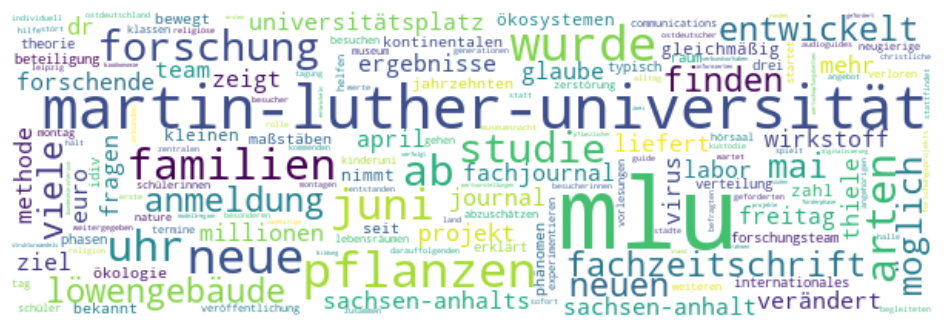

In [9]:
# Generates a Word Cloud image from the word frequencies
wc = WordCloud(width=600, height=200, max_words=200, background_color='white').generate_from_frequencies(word_frequency)
plt.figure(figsize=(12,4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

# Natural language processing (NLP)

How to squeeze textual data into machine learning methods?

## Bag of words

In [10]:
# Text input
malory = ["Do you want ants?",
          "Because that's how you get ants."]

# All unique tokens from the text input (here words, could be n-grams)
feature_names = ['ants', 'because', 'do', 'get', 'how', 'that', 'want', 'you']

# The feature matrix containing the frequency of each token in the text input
feature_matrix = np.array([[1, 0, 1, 0, 0, 0, 1, 1],
                           [1, 1, 0, 1, 1, 1, 0, 1]])

print(pd.DataFrame(feature_matrix, columns=feature_names, index=malory))

                                  ants  because  do  get  how  that  want  you
Do you want ants?                    1        0   1    0    0     0     1    1
Because that's how you get ants.     1        1   0    1    1     1     0    1


Given such a **feature matrix representation**, there are a number of methods, such as [Taddy, M. (2013). "Multinomial inverse regression for text analysis." *Journal of the American Statistical Association*, 108(503), 755-770](https://www.tandfonline.com/doi/pdf/10.1080/01621459.2012.734168?casa_token=JCsl7y3uA0YAAAAA:TWGjlwzreKbZsoVD9_ETwBds-41tbPQQNGYsgqKbdNnMGmrENrxS3DD67d-Tkpfvgbes3BgAZJqM), which allow you to analyze textual data. Think of this conceptually like a simple linear regression, where the **token counts are explanatory variables**. Obviously, the model is heavily over-specified, given the high-dimensional feature matrix. Thus, MNIR is actually a **dimension reduction** technique, much like Lasso regression.


### Sentiment analysis

Sentiment analysis, also referred to as **opinion mining**, is a subfield of Natural Language Processing (NLP) that aims to identify and extract subjective information from text sources. The primary objective is to determine the sentiment expressed in a piece of text, which could be positive, negative, or neutral. 

We typically find **lexicon or glossary based approaches** to sentiment analysis. A lexicon-based approach to sentiment analysis is different from machine learning-based approaches. Machine learning models learn from labelled data, extracting patterns from this data to predict sentiment in unseen data. A sentiment lexicon, such as VADER, however, already has **sentiment scores for each word**, and applies rules to these scores to compute the sentiment of a whole sentence or a text.

[VADER (Valence Aware Dictionary and Sentiment Reasoner)](https://ojs.aaai.org/index.php/icwsm/article/view/14550) is a lexicon and rule-based sentiment analysis tool that is particularly attuned to sentiment expressed in social media contexts. It's used in the field of Natural Language Processing (NLP) to quantify the sentiment of a piece of text, such as a tweet or a review. A similar example is the **non-answer glossary** that will be introduced further below, available at: https://econlinguistics.org/glossary.txt


See:
* https://www.nltk.org/api/nltk.sentiment.vader.html
* https://www.kaggle.com/datasets/nltkdata/vader-lexicon

In [11]:
# Importing necessary libraries
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon if not already downloaded
nltk.download('vader_lexicon')

def analyze_sentiment(article_text):
    sia = SentimentIntensityAnalyzer()
    sentiment = sia.polarity_scores(article_text)
    return sentiment

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\nb\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [12]:
# Positive text
positive_text = "The product is wonderful and the service has been outstanding."
print(f"Positive text polarity: {analyze_sentiment(positive_text)}")

# Negative text
negative_text = "The firm reported a disappointing quarter, with revenues falling short of expectations."
print(f"Negative text polarity: {analyze_sentiment(negative_text)}")

# Neutral text
neutral_text = "The Federal Reserve announced a new interest rate of 0.75%."
print(f"Neutral text polarity: {analyze_sentiment(neutral_text)}")

# Sentiment used in MLU news (note that a mixture of German and English could be a problem here)
print(f"MLU news sentiment: {analyze_sentiment(' '.join(processed_text))}")

Positive text polarity: {'neg': 0.0, 'neu': 0.51, 'pos': 0.49, 'compound': 0.8271}
Negative text polarity: {'neg': 0.348, 'neu': 0.652, 'pos': 0.0, 'compound': -0.5859}
Neutral text polarity: {'neg': 0.0, 'neu': 0.727, 'pos': 0.273, 'compound': 0.4588}
MLU news sentiment: {'neg': 0.0, 'neu': 0.994, 'pos': 0.006, 'compound': 0.34}


### A machine learning approach to measuring **non-answers**

[Barth, A., Mansouri, S., & Woebbeking, F. (2023). “Let Me Get Back to You” — A Machine Learning Approach to Measuring NonAnswers. Management Science, 69(10), 6333-6348.](https://pubsonline.informs.org/doi/pdf/10.1287/mnsc.2022.4597?casa_token=a-68hu3F_iQAAAAA:lqkseC9douDRH7veWc3SlZLjcqSs2npOAc3msF0ikt2zifL3TkyDOW6__xaiUup5MoB4THWpTx8)

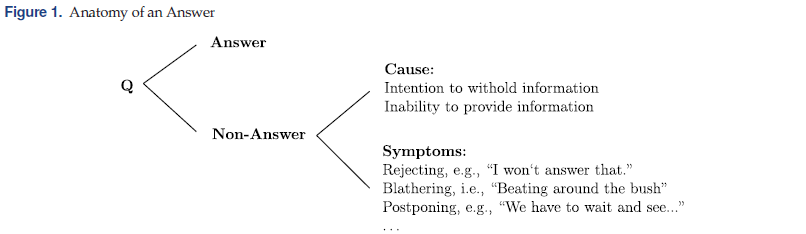

Idea: Train a model on non-answer symptoms to extract a generalizable glossary of tokens that associate with non-answers.

![wordcloud.png](figures/pos_wc-.png)

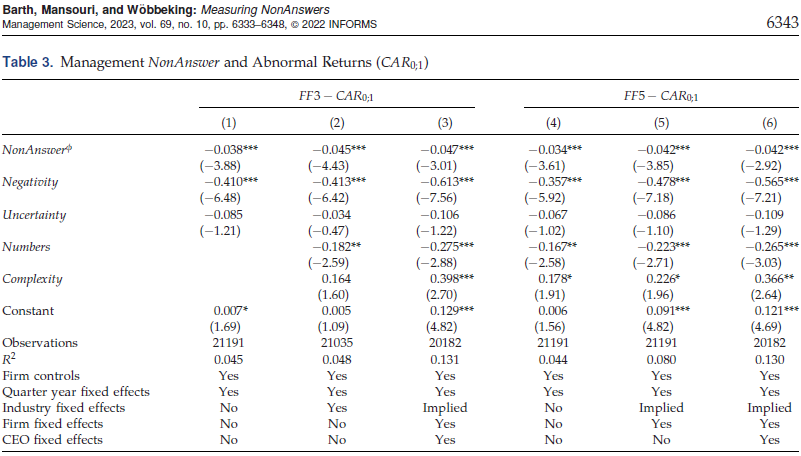

## Word embedding

[Mikolov, T., Sutskever, I., Chen, K., Corrado, G. S., & Dean, J. (2013). Distributed representations of words and phrases and their compositionality. Advances in Neural Information Processing Systems, 26.](https://proceedings.neurips.cc/paper/2013/file/9aa42b31882ec039965f3c4923ce901b-Paper.pdf)

Word embedding is a technique in natural language processing that involves **mapping words into dense, continuous vector representations**, capturing their semantic and syntactic meanings. For example, the word "apple" might have the following embedding:
$$
\vec{v}_\text{apple} = [0.12, -0.34, 0.56, 0.78, -0.01, 0.45, -0.23, 0.67, 0.89, -0.05].
$$

These representations are generated using **unsupervised learning** methods, as they do not require manually labeled data but rely on patterns of word usage within **large text corpora**. Models like [Word2Vec](https://www.tensorflow.org/text/tutorials/word2vec), [GloVe](https://nlp.stanford.edu/projects/glove/), and [FastText](https://fasttext.cc/) recognize relationships between words based on their **contextual co-occurrence** and transform this information into numerical vectors. This approach enables the **encoding of complex linguistic relationships**, improving the performance of tasks such as sentiment analysis and machine translation.

Please note that not only tokens (words) but also entire texts can be represented by vector embeddings. For instance, embeddings used in GPT-3 models can range up to a length of $12,288$.




Visualization: **t-distributed Stochastic Neighbor Embedding (TSNE)**

t-distributed Stochastic Neighbor Embedding (TSNE) is an algorithm for **dimensionality reduction**, useful for visualizing high-dimensional data in a lower-dimensional space (e.g., 2D or 3D). It aims to preserve the local structure of the data by mapping similar points in the high-dimensional space to nearby points in the lower-dimensional space.

![logo.png](figures/tsne.png)



In [13]:
# Simplified word embeddings for cities and countries
word_embeddings = {
    "Paris": np.array([0.8, 0.2, 0.1]),
    "France": np.array([0.7, 0.2, 0.2]),
    "Berlin": np.array([0.6, 0.4, 0.2]),
    "Germany": np.array([0.6, 0.3, 0.3]),
    "Rome": np.array([0.5, 0.6, 0.2]),
    "Italy": np.array([0.5, 0.5, 0.3])
}

# Function to calculate cosine similarity between two vectors
def cosine_similarity(vec_a, vec_b):
    dot_product = np.dot(vec_a, vec_b)
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    return dot_product / (norm_a * norm_b)

print(f"Paris|France: {cosine_similarity(word_embeddings['Paris'], word_embeddings['France']):.2f}")
print(f"Paris|Berlin: {cosine_similarity(word_embeddings['Paris'], word_embeddings['Berlin']):.2f}")
print(f"Paris|Italy:  {cosine_similarity(word_embeddings['Paris'], word_embeddings['Italy']):.2f}")

Paris|France: 0.99
Paris|Berlin: 0.93
Paris|Italy:  0.83


In [ ]:
# Vector arithmetic: Berlin - Germany + France
result_vector = word_embeddings["Berlin"] - word_embeddings["Germany"] + word_embeddings["France"]

# Find the closest word to the resulting vector
closest_city = None
# Start with the smallest possible similarity
max_similarity = -1
for word in ["Paris", "Rome", "Italy"]: 
    similarity = cosine_similarity(result_vector, word_embeddings[word])
    # Update if current embedding is more similar
    if similarity > max_similarity:
        max_similarity = similarity
        closest_word = word

print(f"'Berlin' - 'Germany' + 'France' = '{closest_word}' ({similarity:.2f})")

'Berlin' - 'Germany' + 'France' = 'Paris' (0.90)


## Transformer architecture

[Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., ... & Polosukhin, I. (2017). Attention is all you need. Advances in neural information processing systems, 30.](https://proceedings.neurips.cc/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf)

![logo.png](figures/moore.PNG?c=2)

In [15]:
# Assume that these are the word embeddings for the cities and countries
word_embeddings = {
    "Paris": np.array([0.8, 0.2, 0.1]),
    "France": np.array([0.7, 0.3, 0.2]),
    "Berlin": np.array([0.6, 0.1, 0.2]),
    "Germany": np.array([0.6, 0.4, 0.3]),
    "Rome": np.array([0.5, 0.2, 0.2]),
    "Italy": np.array([0.5, 0.5, 0.3])
    }

In [16]:
# This code is just illustrative ... focus on the steps, not the code!
def transformer_encoder(word_embeddings):
    # Step 1: Input embeddings — vector form of each word (initial meaning)
    word_embeddings = word_embeddings

    # Step 2: Add positional encoding — inject word order info
    positional_embeddings = {word: vec + 0.1 for word, vec in word_embeddings.items()}

    # Step 3: Self-attention (importance of each word in the context of others)
    attention_sum = sum(positional_embeddings.values())
    attention_output = {word: vec * attention_sum for word, vec in positional_embeddings.items()}

    # Step 4: Feed-forward network / non-linear transformation (enables learning of complex patterns beyond attention)
    feed_forward_output = {word: vec + np.array([0.3, 0.3, 0.3]) for word, vec in attention_output.items()}

    return feed_forward_output

In [17]:
# Process the embeddings through the transformer encoder
transformed_embeddings = transformer_encoder(word_embeddings)
display(transformed_embeddings)

{'Paris': array([4.17, 0.99, 0.68]),
 'France': array([3.74, 1.22, 0.87]),
 'Berlin': array([3.31, 0.76, 0.87]),
 'Germany': array([3.31, 1.45, 1.06]),
 'Rome': array([2.88, 0.99, 0.87]),
 'Italy': array([2.88, 1.68, 1.06])}

**Positional Encoding**: This step modifies the original word embeddings by adding a positional value to each element. In real transformers, positional encoding is crucial because it provides information about the position of each word in the sequence. Our simple version just adds 0.1 to every element, but real models use more complex functions for positional encoding.

**Attention**: The self-attention mechanism in transformers allows each position in the encoder to consider every other position in the input sequence when computing its representation. In our example, we simulate self-attention by summing all the positional embeddings and then multiplying each embedding with this sum. This is a vast simplification and doesn't truly represent the selective attention mechanism used in real transformers.

**Feed-Forward Network**: In an actual transformer, each position's output from the self-attention layer is processed by a feed-forward neural network. This network consists of linear transformations and non-linear activations, allowing the model to learn complex transformations of the data. In our example, we simplify this by adding a fixed array [0.3, 0.3, 0.3] to each embedding vector, simulating a very basic transformation.

In [ ]:
# This rule-based classification mimics what a trained **output layer** might do on top of deep LLM embeddings
def classify_city_country(transformed_embeddings):
    classification = {}
    for word, vec in transformed_embeddings.items():
        # Classification rule: if the second element is greater than 1.2, classify as Country, else as City
        classification[word] = "Country" if vec[1] > 1.2 else "City"
    return classification


# Classify each word as City or Country
classification = classify_city_country(transformed_embeddings)

# Displaying the classification results
for word, category in classification.items():
    print(f"{word} is a {category}")

Paris is a City
France is a Country
Berlin is a City
Germany is a Country
Rome is a City
Italy is a Country


### Fine tuning

Large Language Models (LLMs) are often incredibly vast, making training one from scratch a time-consuming and resource-intensive process. Instead, **fine-tuning** involves taking an existing, **pre-trained model** and adjusting it to excel at a specific task or dataset. This adaptation is accomplished through a supervised learning process that involves **updating the model's weights**. By leveraging fine-tuning, developers can significantly reduce the computational burden while achieving more focused, accurate results. For tools, resources, and examples on fine-tuning, visit the Hugging Face platform: https://huggingface.co/.

## ChatGPT API

The OpenAI API allows developers to **integrate advanced AI models like GPT-4** into their applications for tasks like text generation and summarization. To get started, check out the [API Reference](https://platform.openai.com/docs/guides) for detailed guides and examples, or the [Quickstart Tutorial](https://platform.openai.com/docs/quickstart) to quickly set up your first project. You can find cost information for different models on the [API Pricing page](https://platform.openai.com/pricing).

### .ini files

Before we get started, let us introduce a way to **protect your password or api key**. Obviously, you would never want to commit sensitive information to a Git repository. In order to protect my own OpenAI API key, I have stored it in a file called **local.ini**, which I have set to be ignored by Git.

The local.ini file content looks like this:

```Bash
# This is the key that we are after
[openai]
key = geheim123!

# This is just an additional exmaple
[deribit]
account_name = some name
password = geheim123!
```

We can utilize Python's [configparser](https://docs.python.org/3/library/configparser.html) to manage .ini files. By the way, these files are not encrypted on your local machine!

In [19]:
# Load the .ini that includes the OpenAI API key
config = configparser.ConfigParser()
config.read('local.ini')

# Extract the password
openai.api_key = config['openai']['key'].strip()

#print(openai.api_key)  # Try that at home :)

In [20]:
#returns a list of all OpenAI models
models = openai.models.list()
print(f"OpenAI currently offers {len(models.data)} models, e.g.:")
display(models.data[0::5])

OpenAI currently offers 77 models, e.g.:


[Model(id='gpt-4o-realtime-preview-2024-12-17', created=1733945430, object='model', owned_by='system'),
 Model(id='gpt-4o-audio-preview-2024-10-01', created=1727389042, object='model', owned_by='system'),
 Model(id='babbage-002', created=1692634615, object='model', owned_by='system'),
 Model(id='gpt-4o-audio-preview', created=1727460443, object='model', owned_by='system'),
 Model(id='gpt-3.5-turbo-instruct-0914', created=1694122472, object='model', owned_by='system'),
 Model(id='davinci-002', created=1692634301, object='model', owned_by='system'),
 Model(id='o3-mini-2025-01-31', created=1738010200, object='model', owned_by='system'),
 Model(id='text-embedding-3-large', created=1705953180, object='model', owned_by='system'),
 Model(id='o1-mini', created=1725649008, object='model', owned_by='system'),
 Model(id='o1-pro-2025-03-19', created=1742251504, object='model', owned_by='system'),
 Model(id='o1-mini-2024-09-12', created=1725648979, object='model', owned_by='system'),
 Model(id='gpt

### Prompt Engineering

**Prompt engineering** is the practice of crafting clear, purposeful inputs to guide language models toward accurate and useful responses.

Key Tips:
- **Be clear and specific** – Reduce ambiguity with precise wording and context.
- **Frame the task** – Phrase prompts to match the desired output (e.g., summary, explanation).
- **Use examples or constraints** – Show what kind of answer you want.
- **Specify output format** – Ask for JSON, a list, table, etc.
- **Iterate** – Test and refine prompts to improve results.

> You can ask ChatGPT to help improve your prompt!

In [21]:
# Creating the prompt
messages = [{"role": "system", "content": 
    "You are a helpful assistant."}]
messages.append({"role": "user", "content": 
    "Classify into two categories, namely, 'City' and 'Country'"})
messages.append({"role": "user", "content": 
    "Classify this: Germany, Paris, France, Berlin, Rome, Italy"})
messages.append({"role": "user", "content": 
    "The output should be in JSON format."})

### Openai API

In [22]:
# Send prompt to API and retrieve results
completion = openai.chat.completions.create(
                model="gpt-4o", temperature=0.0, seed=2024, messages=messages
            )
print(completion.choices[0].message.content)

```json
{
  "City": ["Paris", "Berlin", "Rome"],
  "Country": ["Germany", "France", "Italy"]
}
```


API parameters https://platform.openai.com/docs/api-reference
* temperature: "What sampling temperature to use, between 0 and 2. Lower values will make it more focused and deterministic."
* seed: "This feature is in Beta. If specified, **our system will make a best effort to sample deterministically**, such that repeated requests with the same seed and parameters should return the same result."

## Constraint-based generation (using functions within an LLM)

Why functions?
* Structured Output: Ensures the model returns clean, **machine-readable JSON**.

* Reliability: Reduces ambiguity and improves consistency of responses.

* Automation-ready: Easily integrates with code, APIs, databases, and workflows.

* Safety: Restricts model outputs to a known schema — useful for critical applications.

> Using function calling with a schema introduces **constraint-based generation** and **separates concerns**: the LLM focuses on the core task (e.g., reasoning or classification), while the schema defines the output format. This improves reliability, reduces ambiguity, and enables programmatic grounding — making the model's outputs easier to integrate into real systems.

In [23]:
# Define the function that the model can call
functions = [
    {
        "name": "classify_locations",
        "description": "Classify a list of place names into either 'City' or 'Country'",
        "parameters": {
            "type": "object",
            "properties": {
                "City": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "All items classified as cities."
                },
                "Country": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "All items classified as countries."
                }
            },
            "required": ["City", "Country"]
        }
    }
]

In [24]:
# Create the chat prompt
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Classify this: Germany, Paris, France, Berlin, Rome, Italy"}
]

In [25]:
# Send prompt to API with function call capability
response = openai.chat.completions.create(
    model="gpt-4o",
    temperature=0.0,
    seed=2024,
    messages=messages,
    functions=functions,  # !!!
    function_call={"name": "classify_locations"}  # force function call
)

print(response.choices[0].message.function_call.arguments)

{"City":["Paris","Berlin","Rome"],"Country":["Germany","France","Italy"]}


## Hallucination is the enemy!

> Hallucinations occur when an AI model confidently generates **false or made-up information** that sounds plausible but is **not grounded in facts or data**.

2025 at a company called „Cursor“:
* Tech support (Bot):  “You are no longer allowed to use Cursor on more than just one computer.”
* Michael Truell (CEO): “We have no such policy. You’re of course free to use Cursor on multiple machines.”

Or as the [New York Times (2025)](https://www.nytimes.com/2025/05/05/technology/ai-hallucinations-chatgpt-google.html) would put it: *"**A.I. Is Getting More Powerful, but Its Hallucinations Are Getting Worse**. A new wave of “reasoning” systems from companies like OpenAI is producing incorrect information more often. Even the companies don’t know why."*

### Input-Conflicting Hallucination:
* The output contradicts the user's input or prompt.
* Example:
    * Input: "List three countries."
    * Output: "Germany, Berlin, and Madrid."

### Content-Conflicting Hallucination
* The output contradicts itself or lacks internal logical consistency.
* **Example:**
  * **Output:** "Alice is an only child. Her brother lives in Canada."

### Fact-Conflicting Hallucination
* The output includes information that contradicts known facts or real-world knowledge.
* **Example:**
  * **Output:** "The Great Wall of China is located in South America."

## Retrieval-Augmented Generation (RAG)

**Retrieval-Augmented Generation (RAG)** is a technique where a large language model combines its internal knowledge with **relevant external information** retrieved at runtime.

A **retriever** component pulls documents or data from a knowledge base or corpus. The **generator** (LLM) then uses both this external content and its own training to produce more accurate, up-to-date, and context-aware answers.

**Example:** A customer support chatbot using RAG retrieves the latest support documentation when asked about a software feature. The LLM then generates an answer that blends this information with its general understanding to give a clear, helpful response.


## Tool-Augmented Generation

**Tool-Augmented Generation** refers to a setup where a language model can **invoke external tools or functions** (e.g. APIs, calculators, databases) to enhance its capabilities.

Instead of generating answers purely from its training, the model **decides when and how to use tools** to get accurate or dynamic results — such as performing calculations, retrieving real-time data, or executing logic.

**Example:** A virtual assistant is asked, "What's the weather in Berlin?" The model calls a weather API (tool) to fetch live data and then uses that result to generate a natural-language response.


## Agentic Systems

**Agentic systems** are AI setups where a language model acts as an **autonomous agent** — making decisions, using tools, and taking multiple steps to achieve a goal.

Rather than just responding to a single prompt, the model can:
- Plan actions
- Use tools (e.g. APIs, calculators)
- Observe outcomes
- Adjust its behavior over time

**Example:** An AI assistant tasked with booking a flight might:
1. Search for available flights (tool call)
2. Compare prices
3. Ask the user to choose
4. Complete the booking

This loop of **observe → reason → act → repeat** gives the system a degree of autonomy.

Useful in complex workflows like research assistants, automation agents, or multi-step problem solving.


## Knowledge Graph

A **Knowledge Graph** is a structured representation of information, where **entities** (nodes) are connected by **relationships** (edges).

It enables AI systems to:
- Represent facts in a machine-readable way
- Perform reasoning over connected data
- Support accurate and explainable retrieval

**Example:** "Paris is the capital of France" becomes:
- Node: Paris  
- Node: France  
- Edge: isCapitalOf

**Use in AI:**  
- Enhances search and retrieval (e.g. Google, chatbots)
- Powers question answering with explicit facts
- Can be used alongside LLMs for grounded reasoning

Helps reduce hallucinations and improve explainability by grounding answers in structured knowledge.


## Multimodal Embedding

A **Multimodal Embedding** is a shared representation space where **different types of data** (e.g., text, images, audio) are encoded into **comparable vector formats**.

This allows AI systems to:
- Compare and relate concepts across modalities
- Perform tasks like image captioning, text-to-image search, or cross-modal reasoning

**Example:** A photo of the Eiffel Tower and the text "Eiffel Tower in Paris" are embedded close together in the vector space — the model understands they refer to the same thing.

**Use cases:**
- Search (e.g., "show me images of ancient temples")
- Extract data from images (e.g. charts) and tables
- Multimodal chatbots and assistants

Enables models to understand and reason across text, images, and beyond in a unified way.